# Demo 11 - Heston diagnostics stability review

This notebook demonstrates the notebook-facing Heston diagnostics workflow that is already implemented under `option_pricing.diagnostics.heston`.

It stays downstream of the pricing engine: we run one report, inspect the packaged `meta`, `tables`, and `arrays`, and render the frozen plot set for convergence, smoothness, continuity, and visible failure modes.

> Tip: if you are running this notebook from the repository rather than an installed package, the next cell adds `src/` to `sys.path` automatically.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

for candidate in (Path.cwd(), *Path.cwd().parents):
    src = candidate / "src"
    if (src / "option_pricing").exists():
        if str(src) not in sys.path:
            sys.path.insert(0, str(src))
        break


## Imports

The one-call report entrypoint is `run_heston_pricing_diagnostics(...)`. The plot helpers live under `option_pricing.diagnostics.heston.plot` so the report surface stays plain-data friendly.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from option_pricing.diagnostics.heston import (
    HestonDiagnosticsReport,
    run_heston_pricing_diagnostics,
)
from option_pricing.diagnostics.heston.plot import (
    plot_backend_difference_by_strike,
    plot_cancellation_ratio_by_strike,
    plot_config_sweep,
    plot_panel_contributions,
    plot_smile_with_warning_overlay,
    plot_tail_fraction_by_strike,
)
from option_pricing.models.heston import HestonParams
from option_pricing.types import MarketData

pd.set_option("display.max_columns", None)


def _display_float(value: float) -> str:
    if pd.isna(value):
        return "NaN"
    scalar = float(value)
    if scalar != 0.0 and abs(scalar) < 1.0e-4:
        return f"{scalar:,.3e}"
    return f"{scalar:,.6f}"


pd.set_option("display.float_format", _display_float)


## Run the one-call report

This is the preferred notebook workflow. The report returns the stable top-level shape `meta`, `tables`, and `arrays` without embedding figures or notebook display state.

This demo intentionally uses a denser strike slice and a mildly stressed short-maturity regime so the recommended Gauss-Legendre config differs from the hard-coded default and the continuity heuristics are not dominated by a very coarse 5-strike grid.


In [3]:
market = MarketData(spot=100.0, rate=0.02, dividend_yield=0.0)
params = HestonParams(kappa=2.0, vbar=0.04, eta=0.80, rho=-0.75, v=0.05)
strike = np.linspace(75.0, 125.0, 17, dtype=np.float64)
tau = 0.15

report_fixed = run_heston_pricing_diagnostics(
    strike=strike,
    tau=tau,
    market=market,
    params=params,
    use_recommended_cfg=False,
)

report = run_heston_pricing_diagnostics(
    strike=strike,
    tau=tau,
    market=market,
    params=params,
    use_recommended_cfg=True,
)

assert isinstance(report_fixed, HestonDiagnosticsReport)
assert isinstance(report, HestonDiagnosticsReport)

fixed_primary_price = np.asarray(
    report_fixed.arrays["slice"]["primary_price"],
    dtype=np.float64,
)
recommended_primary_price = np.asarray(
    report.arrays["slice"]["primary_price"],
    dtype=np.float64,
)

comparison_rows = []
for label, artifact in (("fixed_default", report_fixed), ("recommended", report)):
    cfg = artifact.meta["primary_backend_config"]
    summary = artifact.tables["summary"].set_index("metric")
    comparison_rows.append(
        {
            "scenario": label,
            "primary_backend": artifact.meta["primary_backend"],
            "comparison_backend": artifact.meta["comparison_backend"],
            "config_resolution": cfg["config_resolution"],
            "u_max": cfg["u_max"],
            "n_panels": cfg["n_panels"],
            "nodes_per_panel": cfg["nodes_per_panel"],
            "panel_spacing": cfg["panel_spacing"],
            "max_backend_discrepancy": summary.loc["max_backend_discrepancy", "value"],
            "suspicious_strike_count": summary.loc["suspicious_strike_count", "value"],
        }
    )

pd.DataFrame(comparison_rows).assign(
    max_abs_price_shift_vs_fixed_primary=lambda frame: np.where(
        frame["scenario"] == "fixed_default",
        0.0,
        float(np.max(np.abs(recommended_primary_price - fixed_primary_price))),
    ),
    table_names=", ".join(sorted(report.tables)),
    array_groups=", ".join(sorted(report.arrays)),
)


,scenario,primary_backend,comparison_backend,config_resolution,u_max,n_panels,nodes_per_panel,panel_spacing,max_backend_discrepancy,suspicious_strike_count,max_abs_price_shift_vs_fixed_primary,table_names,array_groups
0,fixed_default,gauss_legendre,quad,default_hard_coded,150.000000,24,16,uniform,0.000130,7.000000,0.000000,"backend_compare, config_sweep, slice, summary,...","backend_compare, comparison_probability_p0, co..."
1,recommended,gauss_legendre,quad,recommended_balanced,240.000000,40,16,uniform,7.561e-07,0.000000,0.000130,"backend_compare, config_sweep, slice, summary,...","backend_compare, comparison_probability_p0, co..."


## Inspect the packaged review surface

The intended reading order is: config provenance first, then `summary`, `slice`, `worst_strikes`, `backend_compare`, `config_sweep`, and finally the worst-panel tables if a strike needs panel-local diagnosis.


In [4]:
config_provenance = pd.DataFrame(
    [
        {"path": "primary", **report.meta["primary_backend_config"]},
        {"path": "comparison", **report.meta["comparison_backend_config"]},
    ]
)

summary = report.tables["summary"]
slice_table = report.tables["slice"]
worst_strikes = report.tables["worst_strikes"]
backend_compare = report.tables["backend_compare"]
config_sweep = report.tables["config_sweep"]
worst_panels_p0 = report.tables["worst_panels_p0"]
worst_panels_p1 = report.tables["worst_panels_p1"]

display(config_provenance)
display(summary)
display(
    slice_table[
        [
            "strike",
            "price",
            "implied_vol",
            "warning_count",
            "severity",
            "backend_diff",
            "config_price_span",
            "smoothness_signal",
            "discontinuity_signal",
            "smoothness_flag",
            "discontinuity_flag",
            "suspicious_flag",
        ]
    ]
)
display(
    worst_strikes[
        [
            "rank",
            "strike",
            "severity",
            "combined_warning_labels",
            "config_price_span",
            "smoothness_signal",
            "discontinuity_signal",
            "suspicious_reasons",
        ]
    ].head(8)
)
display(
    backend_compare[
        [
            "strike",
            "backend_a",
            "backend_b",
            "abs_price_diff",
            "implied_vol_diff",
        ]
    ]
)
display(
    config_sweep[
        [
            "config_label",
            "backend",
            "config_resolution",
            "resolved_u_max",
            "resolved_n_panels",
            "resolved_nodes_per_panel",
            "max_abs_price_diff_vs_baseline",
            "max_abs_probability_diff_p0",
            "max_abs_probability_diff_p1",
            "p0_max_severity",
            "p1_max_severity",
        ]
    ]
)
display(worst_panels_p0.head())
display(worst_panels_p1.head())


,path,backend,config_resolution,u_max,n_panels,nodes_per_panel,panel_spacing,cluster_strength
0,primary,gauss_legendre,recommended_balanced,240.000000,40.000000,16.000000,uniform,2.000000
1,comparison,quad,None,NaN,NaN,NaN,None,NaN


,metric,value,notes,severity
0,worst_strike,118.750000,parameter perturbation instability,ok
1,total_warnings,0.000000,Sum of P0 and P1 warning counts across the str...,ok
2,max_tail_fraction,1.751e-06,Max of the P0/P1 tail fractions at each strike.,ok
3,max_cancellation_ratio,2.748229,Max of the P0/P1 cancellation ratios at each s...,ok
4,max_backend_discrepancy,7.561e-07,Absolute price difference between the primary ...,ok
5,suspicious_strike_count,0.000000,Provisional policy block used for backend diff...,ok


,strike,price,implied_vol,warning_count,severity,backend_diff,config_price_span,smoothness_signal,discontinuity_signal,smoothness_flag,discontinuity_flag,suspicious_flag
0,75.000000,25.279045,0.340000,0,ok,4.565e-09,2.808e-08,NaN,0.042750,False,False,False
1,78.125000,22.207929,0.325465,0,ok,2.633e-07,2.633e-07,0.000482,0.045624,False,False,False
2,81.250000,19.167863,0.310616,0,ok,2.617e-07,2.617e-07,0.000687,0.049178,False,False,False
3,84.375000,16.176845,0.295341,0,ok,5.475e-09,3.151e-08,0.000964,0.053650,False,False,False
4,87.500000,13.261131,0.279495,0,ok,4.711e-07,4.765e-07,0.001351,0.059393,False,False,False
5,90.625000,10.457888,0.262896,0,ok,7.495e-07,7.764e-07,0.001898,0.066940,False,False,False
6,93.750000,7.818261,0.245297,0,ok,1.308e-07,1.559e-07,0.002641,0.077024,False,False,False
7,96.875000,5.411137,0.226404,0,ok,7.561e-07,7.561e-07,0.003297,0.090045,False,False,False
8,100.000000,3.329572,0.206017,0,ok,2.883e-08,4.432e-08,0.001949,0.102854,False,False,False
9,103.125000,1.702404,0.184827,0,ok,6.677e-07,6.876e-07,0.007332,0.102854,False,False,False


,rank,strike,severity,combined_warning_labels,config_price_span,smoothness_signal,discontinuity_signal,suspicious_reasons
0,1,118.750000,ok,none,2.539e-07,0.002740,0.017804,none
1,2,115.625000,ok,none,1.767e-07,0.005894,0.012648,none
2,3,96.875000,ok,none,7.561e-07,0.003297,0.090045,none
3,4,90.625000,ok,none,7.764e-07,0.001898,0.066940,none
4,5,106.250000,ok,none,7.210e-07,0.023018,0.099982,none
5,6,103.125000,ok,none,6.876e-07,0.007332,0.102854,none
6,7,87.500000,ok,none,4.765e-07,0.001351,0.059393,none
7,8,109.375000,ok,none,4.628e-07,0.022972,0.065052,none


,strike,backend_a,backend_b,abs_price_diff,implied_vol_diff
0,75.000000,gauss_legendre,quad,4.565e-09,-3.915e-09
1,78.125000,gauss_legendre,quad,2.633e-07,1.380e-07
2,81.250000,gauss_legendre,quad,2.617e-07,-8.731e-08
3,84.375000,gauss_legendre,quad,5.475e-09,1.213e-09
4,87.500000,gauss_legendre,quad,4.711e-07,7.243e-08
5,90.625000,gauss_legendre,quad,7.495e-07,-8.393e-08
6,93.750000,gauss_legendre,quad,1.308e-07,1.129e-08
7,96.875000,gauss_legendre,quad,7.561e-07,5.391e-08
8,100.000000,gauss_legendre,quad,2.883e-08,1.872e-09
9,103.125000,gauss_legendre,quad,6.677e-07,-4.598e-08


,config_label,backend,config_resolution,resolved_u_max,resolved_n_panels,resolved_nodes_per_panel,max_abs_price_diff_vs_baseline,max_abs_probability_diff_p0,max_abs_probability_diff_p1,p0_max_severity,p1_max_severity
0,primary,gauss_legendre,recommended_balanced,240.000000,40.000000,16.000000,0.000000,0.000000,0.000000,ok,ok
1,comparison,quad,None,NaN,NaN,NaN,7.561e-07,1.248e-07,1.317e-07,ok,ok
2,gauss_robust,gauss_legendre,recommended_robust,300.000000,52.000000,24.000000,7.764e-07,1.252e-07,1.319e-07,ok,ok
3,gauss_balanced,gauss_legendre,recommended_balanced,240.000000,40.000000,16.000000,0.000000,0.000000,0.000000,ok,ok


,rank,point_index,probability_index,backend,log_moneyness,strike,point_severity,point_warning_count,panel_index,panel_start,panel_end,panel_width,panel_contribution,abs_panel_contribution,panel_invalid,reason_code,reason_count,reason_names,reason_labels,severity,severity_rank,detail_available,notes
0,1,3,0,gauss_legendre,0.172899,84.375000,ok,0,10,60.000000,66.000000,6.000000,0.004319,0.004319,True,32,1,oscillation_spike,oscillation spike,severe,3,True,
1,2,1,0,gauss_legendre,0.249860,78.125000,ok,0,11,66.000000,72.000000,6.000000,0.002649,0.002649,True,32,1,oscillation_spike,oscillation spike,severe,3,True,
2,3,0,0,gauss_legendre,0.290682,75.000000,ok,0,0,0.000000,6.000000,6.000000,1.411939,1.411939,True,4,1,underresolved_near_origin,underresolved near origin,warning,2,True,
3,4,1,0,gauss_legendre,0.249860,78.125000,ok,0,0,0.000000,6.000000,6.000000,1.264268,1.264268,True,4,1,underresolved_near_origin,underresolved near origin,warning,2,True,
4,5,16,0,gauss_legendre,-0.220144,125.000000,ok,0,0,0.000000,6.000000,6.000000,-1.162965,1.162965,True,4,1,underresolved_near_origin,underresolved near origin,warning,2,True,


,rank,point_index,probability_index,backend,log_moneyness,strike,point_severity,point_warning_count,panel_index,panel_start,panel_end,panel_width,panel_contribution,abs_panel_contribution,panel_invalid,reason_code,reason_count,reason_names,reason_labels,severity,severity_rank,detail_available,notes
0,1,3,1,gauss_legendre,0.172899,84.375000,ok,0,10,60.000000,66.000000,6.000000,0.004606,0.004606,True,32,1,oscillation_spike,oscillation spike,severe,3,True,
1,2,0,1,gauss_legendre,0.290682,75.000000,ok,0,0,0.000000,6.000000,6.000000,1.440748,1.440748,True,4,1,underresolved_near_origin,underresolved near origin,warning,2,True,
2,3,1,1,gauss_legendre,0.249860,78.125000,ok,0,0,0.000000,6.000000,6.000000,1.296438,1.296438,True,4,1,underresolved_near_origin,underresolved near origin,warning,2,True,
3,4,16,1,gauss_legendre,-0.220144,125.000000,ok,0,0,0.000000,6.000000,6.000000,-1.138136,1.138136,True,4,1,underresolved_near_origin,underresolved near origin,warning,2,True,
4,5,2,1,gauss_legendre,0.210639,81.250000,ok,0,0,0.000000,6.000000,6.000000,1.136631,1.136631,True,4,1,underresolved_near_origin,underresolved near origin,warning,2,True,


## Render the frozen plot set

These plots consume only the packaged report artifacts. They do not call the pricing engine again.


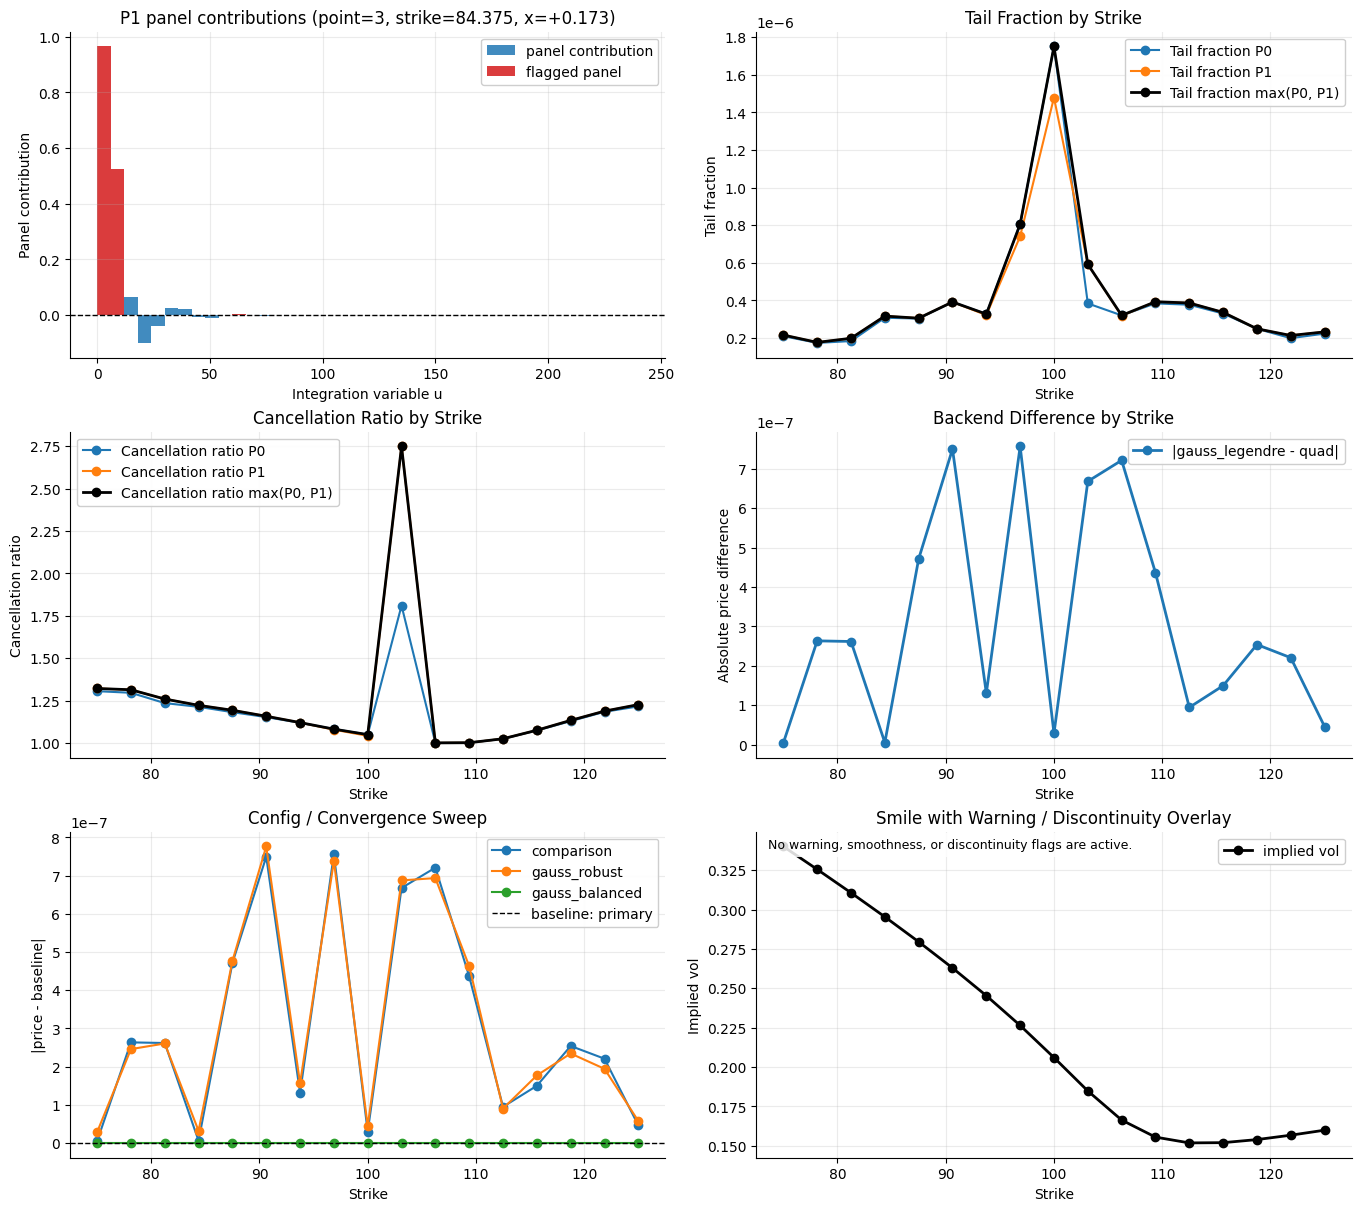

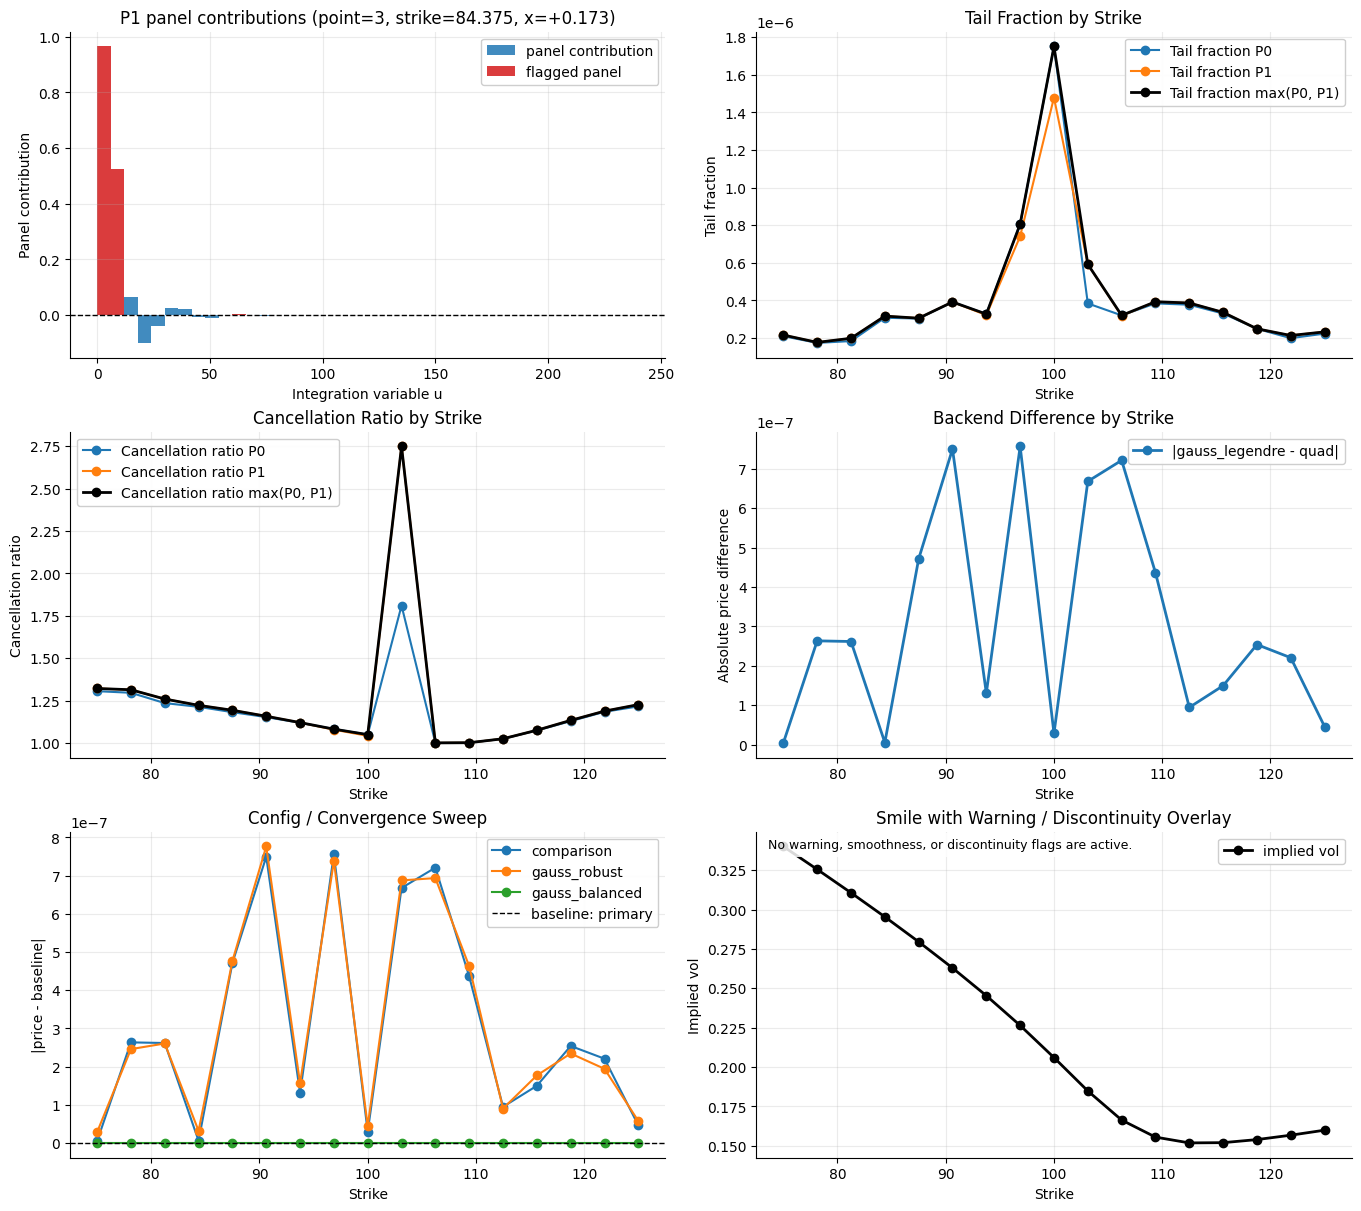

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(13.5, 12.0), constrained_layout=True)

plot_panel_contributions(report, probability_key="probability_p1", ax=axes[0, 0])
plot_tail_fraction_by_strike(report, ax=axes[0, 1])
plot_cancellation_ratio_by_strike(report, ax=axes[1, 0])
plot_backend_difference_by_strike(report, ax=axes[1, 1])
plot_config_sweep(report, ax=axes[2, 0])
plot_smile_with_warning_overlay(report, ax=axes[2, 1])

fig


## Reading the result

- Provenance first: compare the `fixed_default` and `recommended` rows from the run cell, then inspect `report.meta["primary_backend_config"]` / `report.meta["comparison_backend_config"]` and the `config_sweep` discretization columns.
- Convergence: use `config_sweep` and the config-sweep plot to see how much the slice moves under alternate settings. Small values shown in scientific notation are still real movement rather than rounded-away zeros.
- Smoothness and continuity: inspect `smoothness_flag`, `discontinuity_flag`, `smoothness_signal`, `discontinuity_signal`, and the smile overlay. The denser strike grid in this demo is meant to reduce false continuity alarms from coarse spacing.
- Visible failure modes: start with `worst_strikes`, then drill into `worst_panels_p0` or `worst_panels_p1` and the panel-contribution plot.
- Policy note: suspiciousness thresholds and continuity semantics remain provisional. The current implementation is surfaced in `report.meta["provisional_policy"]` rather than hidden in notebook prose.
